# 🏠 Machine Learning Aplicado — Dataset de Imóveis

**Algoritmos abordados:**
1. **Regressão LASSO** — Previsão de preço
2. **Árvore de Decisão** — Classificação de faixa de preço
3. **K-Means** — Clusterização de imóveis (cotovelo + silhueta)

Cada seção inclui: tratamento de dados faltantes, encoding de variáveis categóricas, divisão treino/teste e avaliação com métricas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Regressão
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classificação
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Clusterização
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 📊 1. Carregamento e Análise Exploratória

In [2]:
df = pd.read_csv('dataset_imoveis.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (500, 9)


,regiao,tipo_imovel,area_m2,quartos,vagas_garagem,idade_imovel_anos,distancia_centro_km,preco_reais,faixa_preco
0,Sul,Casa,127.1,4.0,1,27.0,1.40,494143.0,Médio
1,Oeste,Casa,66.6,2.0,3,5.0,9.31,260799.0,Econômico
2,Leste,Apartamento,135.2,3.0,3,28.0,18.93,451451.0,Médio
3,Leste,Sobrado,144.4,2.0,0,16.0,0.50,518875.0,Médio
4,Norte,Casa,142.4,4.0,2,15.0,13.25,444672.0,Médio
5,Norte,Apartamento,163.2,3.0,1,22.0,4.18,548463.0,Médio
6,Norte,Sobrado,153.4,5.0,1,30.0,6.51,469630.0,Médio
7,Oeste,Sobrado,138.4,1.0,2,2.0,26.43,NaN,NaN
8,Leste,Sobrado,117.2,1.0,3,20.0,4.03,462961.0,Médio
9,Leste,Casa,53.6,2.0,3,25.0,6.26,177202.0,Econômico


In [3]:
print('=== Tipos e Nulos ===')
print(df.dtypes)
print('\n=== Valores Nulos ===')
print(df.isnull().sum())
print('\n=== Estatísticas Descritivas ===')
df.describe(include='all')

=== Tipos e Nulos ===
regiao                  object
tipo_imovel             object
area_m2                float64
quartos                float64
vagas_garagem            int64
idade_imovel_anos      float64
distancia_centro_km    float64
preco_reais            float64
faixa_preco             object
dtype: object

=== Valores Nulos ===
regiao                  8
tipo_imovel            10
area_m2                10
quartos                 8
vagas_garagem           0
idade_imovel_anos      12
distancia_centro_km     0
preco_reais            37
faixa_preco            37
dtype: int64

=== Estatísticas Descritivas ===


,regiao,tipo_imovel,area_m2,quartos,vagas_garagem,idade_imovel_anos,distancia_centro_km,preco_reais,faixa_preco
count,492,490,490.000000,492.000000,500.000000,488.00000,500.00000,463.000000,463
unique,4,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Norte,Apartamento,NaN,NaN,NaN,NaN,NaN,NaN,Médio
freq,130,214,NaN,NaN,NaN,NaN,NaN,NaN,314
mean,NaN,NaN,124.568776,2.806911,1.300000,20.45082,9.41972,419273.902808,NaN
std,NaN,NaN,39.176133,1.031733,0.876091,11.28689,9.37799,147333.960392,NaN
min,NaN,NaN,30.000000,1.000000,0.000000,0.00000,0.50000,80000.000000,NaN
25%,NaN,NaN,97.725000,2.000000,1.000000,11.00000,2.72250,320675.000000,NaN
50%,NaN,NaN,125.000000,3.000000,1.000000,20.00000,6.93500,431603.000000,NaN
75%,NaN,NaN,148.375000,3.000000,2.000000,30.00000,11.99250,509280.500000,NaN


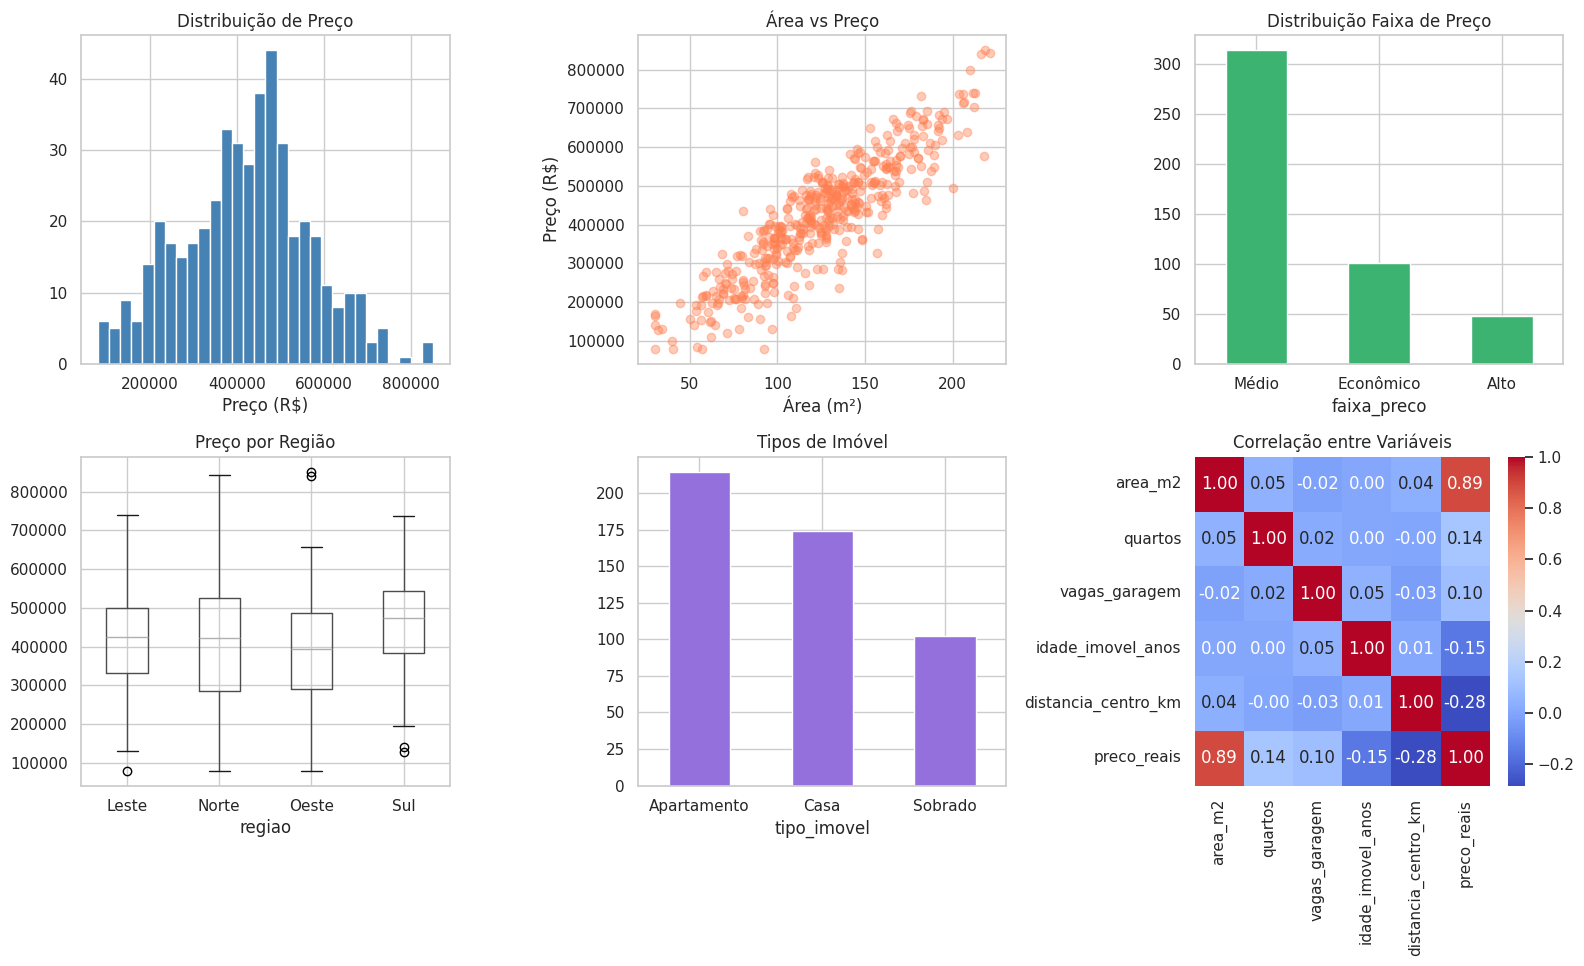

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribuição de preço
axes[0,0].hist(df['preco_reais'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribuição de Preço')
axes[0,0].set_xlabel('Preço (R$)')

# Área vs Preço
axes[0,1].scatter(df['area_m2'], df['preco_reais'], alpha=0.4, color='coral')
axes[0,1].set_title('Área vs Preço')
axes[0,1].set_xlabel('Área (m²)')
axes[0,1].set_ylabel('Preço (R$)')

# Faixa de preço
df['faixa_preco'].value_counts().plot(kind='bar', ax=axes[0,2], color='mediumseagreen')
axes[0,2].set_title('Distribuição Faixa de Preço')
axes[0,2].tick_params(axis='x', rotation=0)

# Boxplot por região
df.boxplot(column='preco_reais', by='regiao', ax=axes[1,0])
axes[1,0].set_title('Preço por Região')
plt.sca(axes[1,0])
plt.suptitle('')

# Tipo de imóvel
df['tipo_imovel'].value_counts().plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Tipos de Imóvel')
axes[1,1].tick_params(axis='x', rotation=0)

# Heatmap correlação
num_cols = ['area_m2','quartos','vagas_garagem','idade_imovel_anos','distancia_centro_km','preco_reais']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlação entre Variáveis')

plt.tight_layout()
plt.show()

---
## 📈 2. REGRESSÃO — Lasso

**Objetivo:** Prever o preço do imóvel (`preco_reais`)

O **LASSO** (Least Absolute Shrinkage and Selection Operator) aplica regularização L1, zerando coeficientes de variáveis irrelevantes — ótimo para seleção automática de features.

In [5]:
# ─── Preparação dos dados para Regressão ───────────────────────────────────────

df_reg = df.dropna(subset=['preco_reais']).copy()  # Remove linhas sem target

TARGET_REG = 'preco_reais'
FEATURES_NUM = ['area_m2', 'quartos', 'vagas_garagem', 'idade_imovel_anos', 'distancia_centro_km']
FEATURES_CAT = ['regiao', 'tipo_imovel']

X = df_reg[FEATURES_NUM + FEATURES_CAT]
y = df_reg[TARGET_REG]

print(f'Linhas após remover nulos no target: {len(df_reg)}')
print(f'Nulos restantes em X:\n{X.isnull().sum()}')

Linhas após remover nulos no target: 463
Nulos restantes em X:
area_m2                0
quartos                0
vagas_garagem          0
idade_imovel_anos      0
distancia_centro_km    0
regiao                 8
tipo_imovel            9
dtype: int64


In [6]:
# ─── Divisão Treino / Teste ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

# ─── Processamento Numérico (Imputação e Padronização) ────────────────────────
# Imputação de nulos nos features numéricos
imputer_num = SimpleImputer(strategy='median')
# Fit apenas nos dados de treino
X_train_num_imputed = imputer_num.fit_transform(X_train[FEATURES_NUM])
# Transforma dados de treino e teste
X_test_num_imputed = imputer_num.transform(X_test[FEATURES_NUM])

# Padronização dos features numéricos
scaler = StandardScaler()
# Fit apenas nos dados de treino
X_train_num_scaled = scaler.fit_transform(X_train_num_imputed)
# Transforma dados de treino e teste
X_test_num_scaled = scaler.transform(X_test_num_imputed)

# Converter para DataFrame para manter os nomes das colunas e índices
X_train_num_processed = pd.DataFrame(X_train_num_scaled, columns=FEATURES_NUM, index=X_train.index)
X_test_num_processed = pd.DataFrame(X_test_num_scaled, columns=FEATURES_NUM, index=X_test.index)


# ─── Processamento Categórico (Imputação e One-Hot Encoding) ──────────────────
# Imputação de nulos nos features categóricos
imputer_cat = SimpleImputer(strategy='most_frequent')
# Fit apenas nos dados de treino
X_train_cat_imputed = imputer_cat.fit_transform(X_train[FEATURES_CAT])
# Transforma dados de treino e teste
X_test_cat_imputed = imputer_cat.transform(X_test[FEATURES_CAT])

# One-Hot Encoding dos features categóricos
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Fit apenas nos dados de treino
X_train_cat_encoded = encoder.fit_transform(X_train_cat_imputed)
# Transforma dados de treino e teste
X_test_cat_encoded = encoder.transform(X_test_cat_imputed)

# Obter nomes das colunas para os features categóricos codificados
cat_feature_names = encoder.get_feature_names_out(FEATURES_CAT)

# Converter para DataFrame para manter os nomes das colunas e índices
X_train_cat_processed = pd.DataFrame(X_train_cat_encoded, columns=cat_feature_names, index=X_train.index)
X_test_cat_processed = pd.DataFrame(X_test_cat_encoded, columns=cat_feature_names, index=X_test.index)


# ─── Combinação de Features ───────────────────────────────────────────────────
X_train_processed = pd.concat([X_train_num_processed, X_train_cat_processed], axis=1)
X_test_processed = pd.concat([X_test_num_processed, X_test_cat_processed], axis=1)

# ─── Modelo Lasso ─────────────────────────────────────────────────────────────
# Definir o modelo Lasso diretamente
model_lasso = Lasso(alpha=1000, random_state=42)

# As variáveis X_train_processed, X_test_processed, y_train, y_test e model_lasso
# estão prontas para serem usadas nas próximas células para treinamento e avaliação.
# A lista 'cat_feature_names' e 'FEATURES_NUM' também são úteis para as próximas etapas.

Treino: 370 amostras | Teste: 93 amostras


In [7]:
model_lasso.fit(X_train_processed, y_train)

Lasso(alpha=1000, random_state=42)

In [8]:
y_pred_reg = model_lasso.predict(X_test_processed)

In [9]:
# ─── Treinamento e Avaliação ───────────────────────────────────────────────────

mae  = mean_absolute_error(y_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2   = r2_score(y_test, y_pred_reg)

print('═' * 45)
print('        MÉTRICAS — REGRESSÃO LASSO')
print('═' * 45)
print(f'  MAE  (Erro Médio Absoluto)  : R$ {mae:,.0f}')
print(f'  RMSE (Raiz do Erro Quadr.)  : R$ {rmse:,.0f}')
print(f'  R²   (Coef. de Determinação): {r2:.4f}')
print('═' * 45)
print()
print('📌 Interpretação:')
print(f'  • R² = {r2:.2f} → o modelo explica {r2*100:.1f}% da variância do preço')
print(f'  • Em média, erra R$ {mae:,.0f} por imóvel (MAE)')

═════════════════════════════════════════════
        MÉTRICAS — REGRESSÃO LASSO
═════════════════════════════════════════════
  MAE  (Erro Médio Absoluto)  : R$ 17,424
  RMSE (Raiz do Erro Quadr.)  : R$ 21,776
  R²   (Coef. de Determinação): 0.9763
═════════════════════════════════════════════

📌 Interpretação:
  • R² = 0.98 → o modelo explica 97.6% da variância do preço
  • Em média, erra R$ 17,424 por imóvel (MAE)


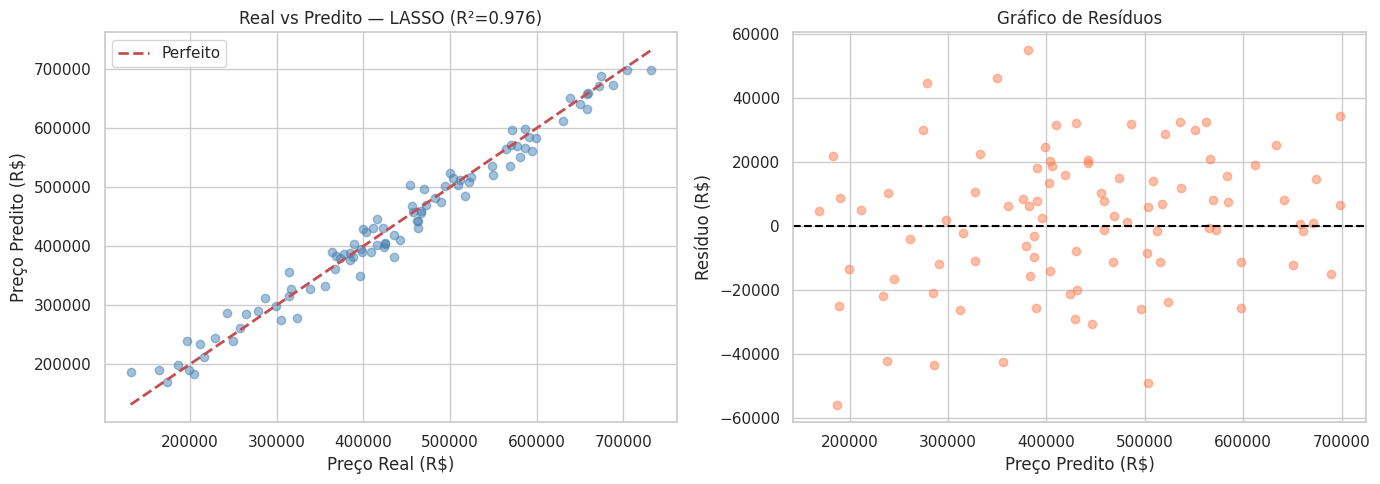

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predito vs Real
axes[0].scatter(y_test, y_pred_reg, alpha=0.5, color='steelblue')
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfeito')
axes[0].set_xlabel('Preço Real (R$)')
axes[0].set_ylabel('Preço Predito (R$)')
axes[0].set_title(f'Real vs Predito — LASSO (R²={r2:.3f})')
axes[0].legend()

# Resíduos
residuos = y_test - y_pred_reg
axes[1].scatter(y_pred_reg, residuos, alpha=0.5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Preço Predito (R$)')
axes[1].set_ylabel('Resíduo (R$)')
axes[1].set_title('Gráfico de Resíduos')

plt.tight_layout()
plt.show()

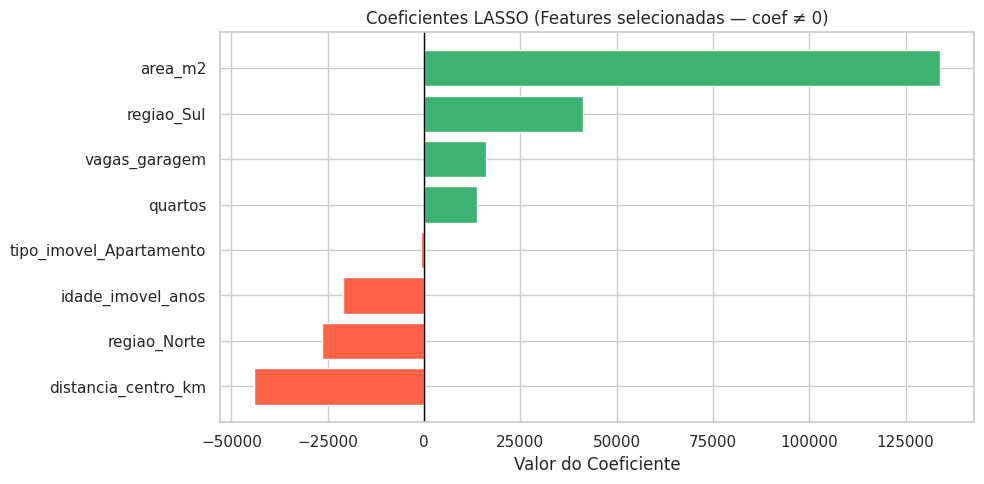


📌 LASSO zerou automaticamente features irrelevantes (seleção automática de variáveis)


In [11]:


# ─── Coeficientes do LASSO ────────────────────────────────────────────────────

all_feature_names = FEATURES_NUM + list(cat_feature_names)

coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coeficiente': model_lasso.coef_})
coef_df = coef_df[coef_df['Coeficiente'] != 0].sort_values('Coeficiente')

colors = ['tomato' if c < 0 else 'mediumseagreen' for c in coef_df['Coeficiente']]
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
plt.axvline(0, color='black', lw=1)
plt.title('Coeficientes LASSO (Features selecionadas — coef ≠ 0)')
plt.xlabel('Valor do Coeficiente')
plt.tight_layout()
plt.show()
print('\n📌 LASSO zerou automaticamente features irrelevantes (seleção automática de variáveis)')

---
## 🌳 3. CLASSIFICAÇÃO — Árvore de Decisão

**Objetivo:** Classificar o imóvel em `Econômico`, `Médio` ou `Alto`

A **Árvore de Decisão** cria regras hierárquicas de separação — altamente interpretável e não requer normalização.

In [12]:
# ─── Preparação dos dados para Classificação ──────────────────────────────────

df_clf = df.dropna(subset=['faixa_preco']).copy()

TARGET_CLF = 'faixa_preco'

X_clf = df_clf[FEATURES_NUM + FEATURES_CAT]
y_clf = df_clf[TARGET_CLF]

print(f'Distribuição das classes:\n{y_clf.value_counts()}')

Distribuição das classes:
faixa_preco
Médio        314
Econômico    101
Alto          48
Name: count, dtype: int64


In [13]:
# ─── Divisão Treino/Teste ──────────────────────────────────────────
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Treino: {X_train_c.shape[0]} | Teste: {X_test_c.shape[0]}')
print(f'Classes: {y_clf.unique().tolist()}')

# ─── Processamento Numérico (Imputação) ────────────────────────
# Para Árvores de Decisão, a padronização (scaling) não é estritamente necessária,
# mas a imputação de nulos é importante.
imputer_num_clf = SimpleImputer(strategy='median')

X_train_c_num_imputed = imputer_num_clf.fit_transform(X_train_c[FEATURES_NUM])
X_test_c_num_imputed = imputer_num_clf.transform(X_test_c[FEATURES_NUM])

X_train_c_num_processed = pd.DataFrame(X_train_c_num_imputed, columns=FEATURES_NUM, index=X_train_c.index)
X_test_c_num_processed = pd.DataFrame(X_test_c_num_imputed, columns=FEATURES_NUM, index=X_test_c.index)

# ─── Processamento Categórico (Imputação e One-Hot Encoding) ──────────────────
imputer_cat_clf = SimpleImputer(strategy='most_frequent')

X_train_c_cat_imputed = imputer_cat_clf.fit_transform(X_train_c[FEATURES_CAT])
X_test_c_cat_imputed = imputer_cat_clf.transform(X_test_c[FEATURES_CAT])

encoder_clf = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_c_cat_encoded = encoder_clf.fit_transform(X_train_c_cat_imputed)
X_test_c_cat_encoded = encoder_clf.transform(X_test_c_cat_imputed)

cat_feature_names_clf = encoder_clf.get_feature_names_out(FEATURES_CAT)

X_train_c_cat_processed = pd.DataFrame(X_train_c_cat_encoded, columns=cat_feature_names_clf, index=X_train_c.index)
X_test_c_cat_processed = pd.DataFrame(X_test_c_cat_encoded, columns=cat_feature_names_clf, index=X_test_c.index)

# ─── Combinação de Features ───────────────────────────────────────────────────
X_train_c_processed = pd.concat([X_train_c_num_processed, X_train_c_cat_processed], axis=1)
X_test_c_processed = pd.concat([X_test_c_num_processed, X_test_c_cat_processed], axis=1)

# ─── Modelo de Árvore de Decisão ─────────────────────────────────────────────
dt_model_no_pipeline = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)

# As variáveis X_train_c_processed, X_test_c_processed, y_train_c, y_test_c e dt_model_no_pipeline
# estão prontas para serem usadas nas próximas células para treinamento e avaliação.
# A lista 'cat_feature_names_clf' e 'FEATURES_NUM' também são úteis para as próximas etapas.

Treino: 370 | Teste: 93
Classes: ['Médio', 'Econômico', 'Alto']


In [14]:
X_train_c_processed

,area_m2,quartos,vagas_garagem,idade_imovel_anos,distancia_centro_km,regiao_Leste,regiao_Norte,regiao_Oeste,regiao_Sul,tipo_imovel_Apartamento,tipo_imovel_Casa,tipo_imovel_Sobrado
331,128.7,3.0,1.0,25.0,0.50,0.0,0.0,1.0,0.0,0.0,1.0,0.0
16,118.4,3.0,2.0,15.0,7.94,0.0,0.0,0.0,1.0,1.0,0.0,0.0
168,118.2,3.0,1.0,14.0,1.77,0.0,1.0,0.0,0.0,1.0,0.0,0.0
305,137.2,1.0,0.0,19.0,7.79,0.0,0.0,1.0,0.0,0.0,1.0,0.0
278,141.7,2.0,2.0,9.0,2.57,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
159,97.4,4.0,1.0,22.0,27.29,1.0,0.0,0.0,0.0,0.0,1.0,0.0
264,113.1,4.0,0.0,3.0,15.34,0.0,0.0,1.0,0.0,1.0,0.0,0.0
217,145.6,4.0,1.0,36.0,8.83,0.0,0.0,1.0,0.0,0.0,0.0,1.0
19,121.2,3.0,3.0,39.0,10.90,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [15]:
# ─── Treinamento e Avaliação ───────────────────────────────────────────────────
dt_model_no_pipeline.fit(X_train_c_processed, y_train_c)
y_pred_clf = dt_model_no_pipeline.predict(X_test_c_processed)

acc = accuracy_score(y_test_c, y_pred_clf)

print('═' * 50)
print('     MÉTRICAS — CLASSIFICAÇÃO (Árvore de Decisão)')
print('═' * 50)
print(f'  Acurácia: {acc:.4f} ({acc*100:.1f}%)')
print('═' * 50)
print()
print('─── Relatório de Classificação ───────────────────')
print(classification_report(y_test_c, y_pred_clf))
print()
print('📌 Métricas por classe:')
print('  • Precision: dos que o modelo previu como X, quantos são realmente X?')
print('  • Recall:    dos que são realmente X, quantos o modelo identificou?')
print('  • F1-Score:  média harmônica entre Precision e Recall')

══════════════════════════════════════════════════
     MÉTRICAS — CLASSIFICAÇÃO (Árvore de Decisão)
══════════════════════════════════════════════════
  Acurácia: 0.7957 (79.6%)
══════════════════════════════════════════════════

─── Relatório de Classificação ───────────────────
              precision    recall  f1-score   support

        Alto       0.75      0.90      0.82        10
   Econômico       0.58      0.90      0.71        20
       Médio       0.94      0.75      0.83        63

    accuracy                           0.80        93
   macro avg       0.76      0.85      0.79        93
weighted avg       0.84      0.80      0.80        93


📌 Métricas por classe:
  • Precision: dos que o modelo previu como X, quantos são realmente X?
  • Recall:    dos que são realmente X, quantos o modelo identificou?
  • F1-Score:  média harmônica entre Precision e Recall


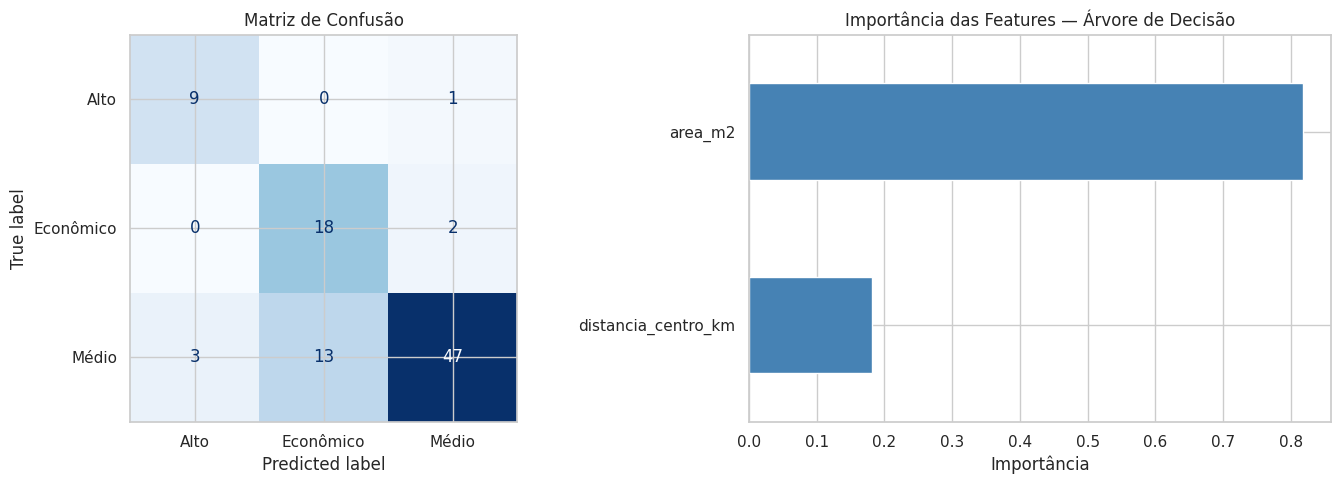

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
# As classes precisam ser obtidas diretamente da variável target y_clf e ordenadas
classes = sorted(y_clf.unique().tolist())
cm = confusion_matrix(y_test_c, y_pred_clf, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão')

# Importância das Features
dt_model = dt_model_no_pipeline # Usar o modelo diretamente definido
# cat_feature_names_clf já está definido após o processamento manual
feat_names_clf = FEATURES_NUM + list(cat_feature_names_clf)

importances = pd.Series(dt_model.feature_importances_, index=feat_names_clf)
importances = importances[importances > 0].sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Importância das Features — Árvore de Decisão')
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.show()

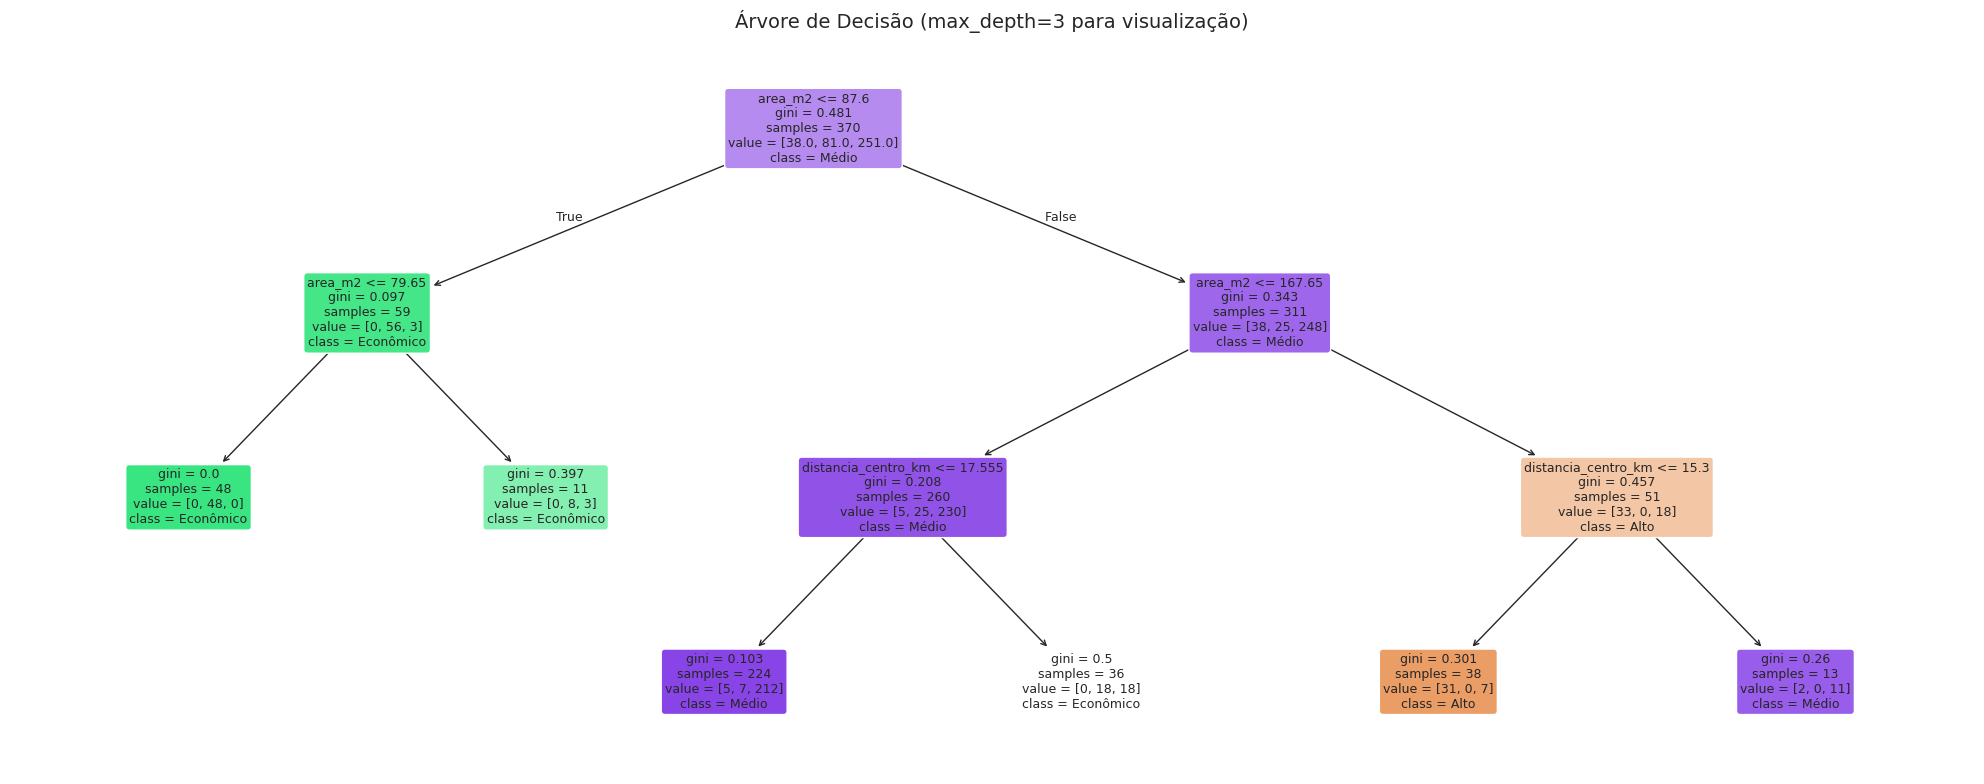

In [17]:
# ─── Visualização da Árvore de Decisão ────────────────────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feat_names_clf,
    class_names=classes,
    filled=True,
    max_depth=3,       # Exibe até profundidade 3 para legibilidade
    fontsize=9,
    rounded=True
)
plt.title('Árvore de Decisão (max_depth=3 para visualização)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 🔵 4. CLUSTERIZAÇÃO — K-Means

**Objetivo:** Agrupar imóveis em perfis similares sem usar o target

Usaremos o **método do cotovelo** (Elbow) e o **índice de silhueta** para determinar o k ideal.

In [18]:
# ─── Preparação dos dados para Clusterização ──────────────────────────────────
# K-Means usa apenas features numéricas após transformação

df_clus = df.copy()

FEATURES_CLUS_NUM = ['area_m2', 'quartos', 'vagas_garagem', 'idade_imovel_anos', 'distancia_centro_km', 'preco_reais']
FEATURES_CLUS_CAT = ['regiao', 'tipo_imovel']

X_clus = df_clus[FEATURES_CLUS_NUM + FEATURES_CLUS_CAT]

# Processamento Numérico (Imputação e Padronização)
imputer_clus_num = SimpleImputer(strategy='median')
X_clus_num_imputed = imputer_clus_num.fit_transform(X_clus[FEATURES_CLUS_NUM])

scaler_clus = StandardScaler()
X_clus_num_scaled = scaler_clus.fit_transform(X_clus_num_imputed)

# Processamento Categórico (Imputação e One-Hot Encoding)
imputer_clus_cat = SimpleImputer(strategy='most_frequent')
X_clus_cat_imputed = imputer_clus_cat.fit_transform(X_clus[FEATURES_CLUS_CAT])

encoder_clus = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_clus_cat_encoded = encoder_clus.fit_transform(X_clus_cat_imputed)

# Combinação de Features
X_clus_prep = np.concatenate([X_clus_num_scaled, X_clus_cat_encoded], axis=1)

print(f'Shape após pré-processamento: {X_clus_prep.shape}')

Shape após pré-processamento: (500, 13)


In [19]:
X_clus_prep

array([[ 0.06511137,  1.16359509, -0.34277321, ...,  0.        ,
         1.        ,  0.        ],
       [-1.49646723, -0.79202691,  1.94238152, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.27418223,  0.18578409,  1.94238152, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.28708784,  1.16359509,  0.79980415, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.0805981 ,  0.18578409, -1.48535057, ...,  0.        ,
         0.        ,  1.        ],
       [-0.43820735, -0.79202691, -1.48535057, ...,  0.        ,
         1.        ,  0.        ]])

In [20]:
# ─── Método do Cotovelo + Silhueta ────────────────────────────────────────────
k_range = range(2, 20)
inertias = []
silhouettes = []

print('Calculando K-Means para K=2 até K=10...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clus_prep)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clus_prep, labels)
    silhouettes.append(sil)
    print(f'  K={k:2d} | Inércia={km.inertia_:,.0f} | Silhueta={sil:.4f}')

print('\n✅ Cálculo concluído!')

Calculando K-Means para K=2 até K=10...
  K= 2 | Inércia=3,082 | Silhueta=0.1505
  K= 3 | Inércia=2,809 | Silhueta=0.1461
  K= 4 | Inércia=2,592 | Silhueta=0.1185
  K= 5 | Inércia=2,407 | Silhueta=0.1143
  K= 6 | Inércia=2,267 | Silhueta=0.1153
  K= 7 | Inércia=2,152 | Silhueta=0.1181
  K= 8 | Inércia=2,064 | Silhueta=0.1155
  K= 9 | Inércia=1,996 | Silhueta=0.1119
  K=10 | Inércia=1,925 | Silhueta=0.1132
  K=11 | Inércia=1,888 | Silhueta=0.1082
  K=12 | Inércia=1,840 | Silhueta=0.1033
  K=13 | Inércia=1,803 | Silhueta=0.1050
  K=14 | Inércia=1,750 | Silhueta=0.1075
  K=15 | Inércia=1,730 | Silhueta=0.0998
  K=16 | Inércia=1,690 | Silhueta=0.0992
  K=17 | Inércia=1,669 | Silhueta=0.0999
  K=18 | Inércia=1,650 | Silhueta=0.1021
  K=19 | Inércia=1,609 | Silhueta=0.0998

✅ Cálculo concluído!


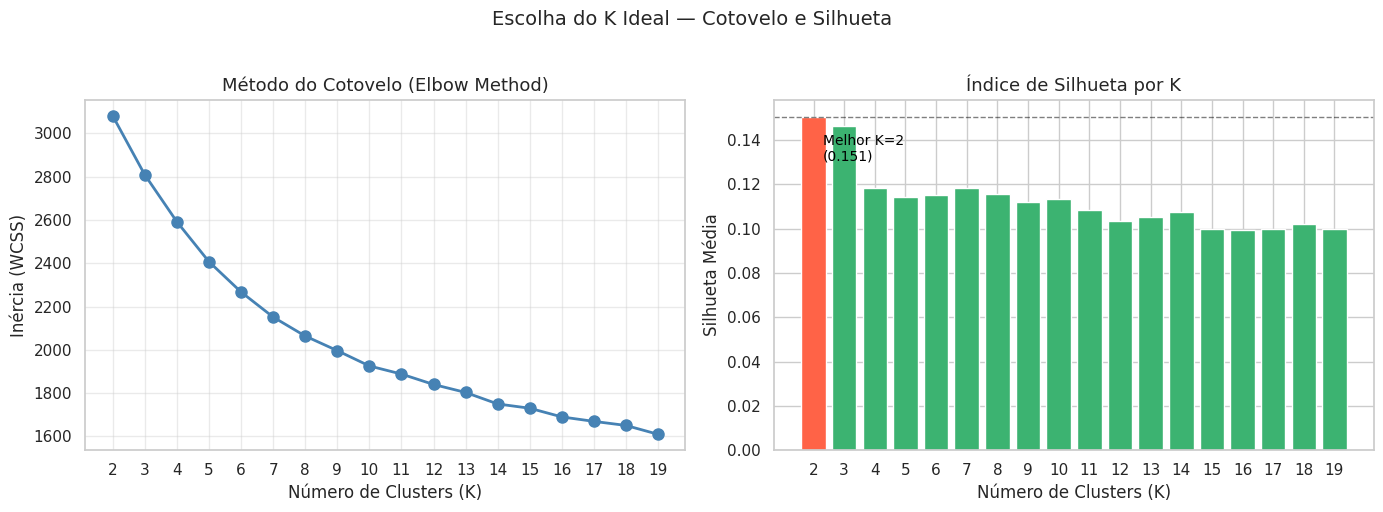


📌 Melhor K pelo índice de silhueta: K=2 (silhueta=0.1505)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cotovelo
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Método do Cotovelo (Elbow Method)', fontsize=13)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.4)

# Silhueta
best_k_sil = list(k_range)[np.argmax(silhouettes)]
bar_colors = ['tomato' if k == best_k_sil else 'mediumseagreen' for k in k_range]
axes[1].bar(list(k_range), silhouettes, color=bar_colors, edgecolor='white')
axes[1].set_title('Índice de Silhueta por K', fontsize=13)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhueta Média')
axes[1].set_xticks(list(k_range))
axes[1].axhline(max(silhouettes), color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].annotate(f'Melhor K={best_k_sil}\n({max(silhouettes):.3f})',
                 xy=(best_k_sil, max(silhouettes)), xytext=(best_k_sil+0.3, max(silhouettes)-0.02),
                 fontsize=10, color='black')

plt.suptitle('Escolha do K Ideal — Cotovelo e Silhueta', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📌 Melhor K pelo índice de silhueta: K={best_k_sil} (silhueta={max(silhouettes):.4f})')

In [22]:
# ─── Modelo Final com K escolhido ─────────────────────────────────────────────
K_FINAL = best_k_sil
print(f'Treinando K-Means com K={K_FINAL}...')

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_clus_prep)

df_clus['cluster'] = cluster_labels

sil_final = silhouette_score(X_clus_prep, cluster_labels)

print('═' * 45)
print('       MÉTRICAS — CLUSTERIZAÇÃO K-MEANS')
print('═' * 45)
print(f'  K (clusters)    : {K_FINAL}')
print(f'  Inércia (WCSS)  : {km_final.inertia_:,.0f}')
print(f'  Silhueta Média  : {sil_final:.4f}')
print('═' * 45)
print()
print('📌 Interpretação da Silhueta:')
print('  • 0.7–1.0 → Clusters excelentes')
print('  • 0.5–0.7 → Estrutura razoável')
print('  • 0.25–0.5 → Estrutura fraca')
print('  • < 0.25  → Sem estrutura clara')
print()
print('Tamanho de cada cluster:')
print(df_clus['cluster'].value_counts().sort_index())

Treinando K-Means com K=2...
═════════════════════════════════════════════
       MÉTRICAS — CLUSTERIZAÇÃO K-MEANS
═════════════════════════════════════════════
  K (clusters)    : 2
  Inércia (WCSS)  : 3,082
  Silhueta Média  : 0.1505
═════════════════════════════════════════════

📌 Interpretação da Silhueta:
  • 0.7–1.0 → Clusters excelentes
  • 0.5–0.7 → Estrutura razoável
  • 0.25–0.5 → Estrutura fraca
  • < 0.25  → Sem estrutura clara

Tamanho de cada cluster:
cluster
0    214
1    286
Name: count, dtype: int64


In [23]:
# ─── Perfil de cada Cluster ───────────────────────────────────────────────────
profile = df_clus.groupby('cluster')[FEATURES_CLUS_NUM].mean().round(1)
print('=== Perfil Médio por Cluster ===')
profile

=== Perfil Médio por Cluster ===


,area_m2,quartos,vagas_garagem,idade_imovel_anos,distancia_centro_km,preco_reais
cluster,,,,,,
0,92.0,2.6,1.3,20.9,12.1,286347.4
1,149.8,3.0,1.3,20.1,7.4,522151.9


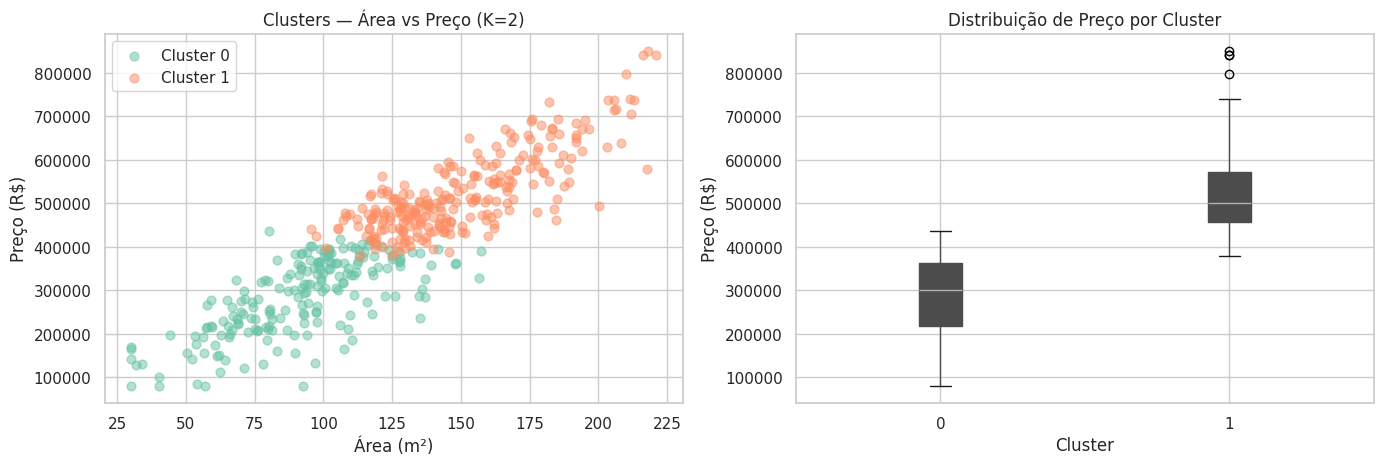

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('Set2', K_FINAL)

# Scatter: Área vs Preço por Cluster
for cl in range(K_FINAL):
    mask = df_clus['cluster'] == cl
    axes[0].scatter(
        df_clus.loc[mask, 'area_m2'],
        df_clus.loc[mask, 'preco_reais'],
        label=f'Cluster {cl}',
        alpha=0.5, s=40, color=palette[cl]
    )
axes[0].set_xlabel('Área (m²)')
axes[0].set_ylabel('Preço (R$)')
axes[0].set_title(f'Clusters — Área vs Preço (K={K_FINAL})')
axes[0].legend()

# Boxplot de preço por Cluster
df_clus.boxplot(column='preco_reais', by='cluster', ax=axes[1],
               patch_artist=True)
axes[1].set_title(f'Distribuição de Preço por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Preço (R$)')
plt.suptitle('')

plt.tight_layout()
plt.show()

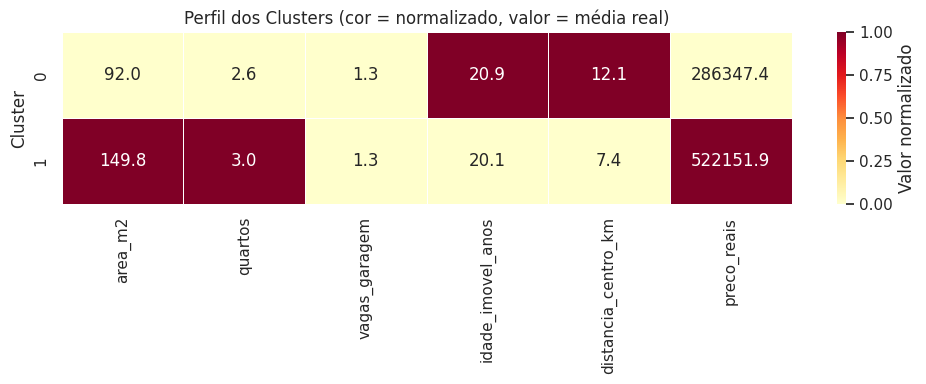

In [25]:
# ─── Heatmap de perfil dos clusters ───────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

profile_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(profile),
    index=profile.index,
    columns=profile.columns
)

plt.figure(figsize=(10, 4))
sns.heatmap(profile_scaled, annot=profile.values, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Valor normalizado'})
plt.title('Perfil dos Clusters (cor = normalizado, valor = média real)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

---
## 📋 5. Resumo Final

In [26]:
print('╔══════════════════════════════════════════════════════╗')
print('║          RESUMO DOS MODELOS TREINADOS                ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║ REGRESSÃO LASSO                                      ║')
print(f'║   MAE  : R$ {mae:>10,.0f}                              ║')
print(f'║   RMSE : R$ {rmse:>10,.0f}                              ║')
print(f'║   R²   :     {r2:.4f}                                ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║ CLASSIFICAÇÃO — Árvore de Decisão                    ║')
print(f'║   Acurácia      : {acc:.4f} ({acc*100:.1f}%)                   ║')
print(f'║   Classes       : Econômico | Médio | Alto           ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║ CLUSTERIZAÇÃO — K-Means                              ║')
print(f'║   K escolhido   : {K_FINAL}                                    ║')
print(f'║   Silhueta      : {sil_final:.4f}                             ║')
print(f'║   Inércia       : {km_final.inertia_:>10,.0f}                      ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║          RESUMO DOS MODELOS TREINADOS                ║
╠══════════════════════════════════════════════════════╣
║ REGRESSÃO LASSO                                      ║
║   MAE  : R$     17,424                              ║
║   RMSE : R$     21,776                              ║
║   R²   :     0.9763                                ║
╠══════════════════════════════════════════════════════╣
║ CLASSIFICAÇÃO — Árvore de Decisão                    ║
║   Acurácia      : 0.7957 (79.6%)                   ║
║   Classes       : Econômico | Médio | Alto           ║
╠══════════════════════════════════════════════════════╣
║ CLUSTERIZAÇÃO — K-Means                              ║
║   K escolhido   : 2                                    ║
║   Silhueta      : 0.1505                             ║
║   Inércia       :      3,082                      ║
╚══════════════════════════════════════════════════════╝


In [27]:
# Dbscan

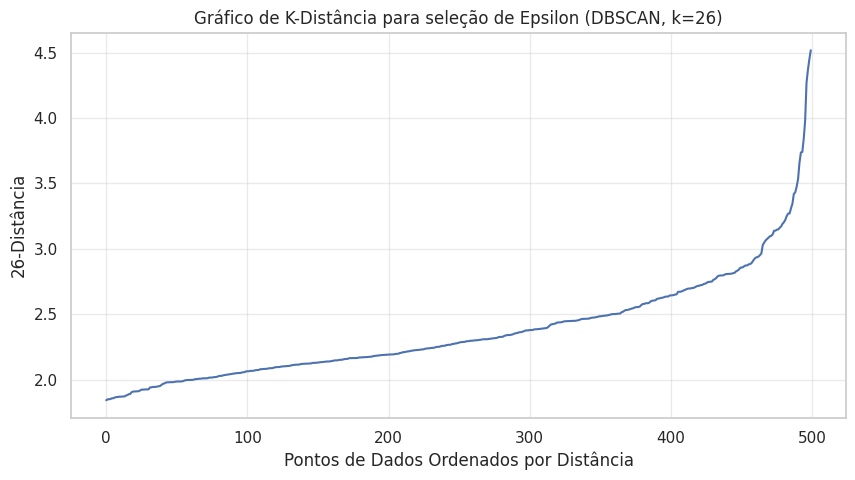


📌 O gráfico de K-Distância (para k=26) foi gerado acima.
   Procure pelo 'cotovelo' no gráfico. Este ponto de inflexão sugere um valor apropriado para 'eps'.
   Por exemplo, se o cotovelo estiver em y=0.8, defina EPS_DBSCAN = 0.8.

Treinando DBSCAN com eps=0.8 e min_samples=26...
═════════════════════════════════════════════
       MÉTRICAS — CLUSTERIZAÇÃO DBSCAN
═════════════════════════════════════════════
  Número estimado de clusters: 0
  Número de pontos de ruído:   500
  Parâmetros: eps=0.8, min_samples=26
═════════════════════════════════════════════
  Silhueta Média: Não calculada (menos de 2 clusters válidos ou apenas ruído).
═════════════════════════════════════════════

Distribuição dos clusters:
cluster_dbscan
-1    500
Name: count, dtype: int64

Não foi possível perfilar ou visualizar clusters válidos (apenas ruído ou menos de 2 clusters encontrados).

📌 DBSCAN é sensível aos parâmetros `eps` e `min_samples`. Ajuste `EPS_DBSCAN` e `min_samples_dbscan` para explorar difere

In [29]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# --- Preparação dos dados para Clusterização DBSCAN ──────────────────────────────────
# X_clus_prep já está preparado e escalado da seção K-Means (contém features numéricas e categóricas one-hot encoded)
# Shape: (500, 13)

# --- Escolha de Parâmetros (eps e min_samples) ────────────────────────────────────
# min_samples: Regra geral é 2 * n_features
n_features_dbscan = X_clus_prep.shape[1]
min_samples_dbscan = 2 * n_features_dbscan # = 2 * 13 = 26

# Para eps: Usar o gráfico de k-distância para o (min_samples_dbscan-1)-ésimo vizinho mais próximo
# Isso ajuda a encontrar a distância onde a densidade dos pontos começa a diminuir significativamente.
neigh = NearestNeighbors(n_neighbors=min_samples_dbscan)
distances, indices = neigh.fit(X_clus_prep).kneighbors(X_clus_prep)

# Ordenar as distâncias para o k-ésimo vizinho e plotar para encontrar o 'cotovelo'
distances = np.sort(distances[:, min_samples_dbscan-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title(f'Gráfico de K-Distância para seleção de Epsilon (DBSCAN, k={min_samples_dbscan})')
plt.xlabel('Pontos de Dados Ordenados por Distância')
plt.ylabel(f'{min_samples_dbscan}-Distância')
plt.grid(True, alpha=0.4)
plt.show()

print(f"\n📌 O gráfico de K-Distância (para k={min_samples_dbscan}) foi gerado acima.")
print("   Procure pelo 'cotovelo' no gráfico. Este ponto de inflexão sugere um valor apropriado para 'eps'.")
print("   Por exemplo, se o cotovelo estiver em y=0.8, defina EPS_DBSCAN = 0.8.")

# --- Modelo DBSCAN ────────────────────────────────────────────────────────────
# ! IMPORTANTE: Ajuste o valor de EPS_DBSCAN abaixo com base na sua análise do gráfico de K-Distância !
EPS_DBSCAN = 0.8 # Valor inicial de exemplo. Ajuste com base no gráfico acima!

print(f'\nTreinando DBSCAN com eps={EPS_DBSCAN} e min_samples={min_samples_dbscan}...')

dbscan_model = DBSCAN(eps=EPS_DBSCAN, min_samples=min_samples_dbscan)
dbscan_labels = dbscan_model.fit_predict(X_clus_prep)

# Adicionar os labels dos clusters ao DataFrame original para análise
df_clus_dbscan = df.copy() # Criar uma nova cópia para não sobrescrever df_clus do K-Means
df_clus_dbscan['cluster_dbscan'] = dbscan_labels

# --- Avaliação e Métricas ───────────────────────────────────────────────────────
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0) # Ignora pontos de ruído
n_noise_ = list(dbscan_labels).count(-1)

print('═' * 45)
print('       MÉTRICAS — CLUSTERIZAÇÃO DBSCAN')
print('═' * 45)
print(f'  Número estimado de clusters: {n_clusters_}')
print(f'  Número de pontos de ruído:   {n_noise_}')
print(f'  Parâmetros: eps={EPS_DBSCAN}, min_samples={min_samples_dbscan}')
print('═' * 45)

if n_clusters_ >= 2: # Silhouette score requer pelo menos 2 clusters (excluindo ruído)
    # Excluir pontos de ruído (-1) para calcular o silhouette score
    core_samples_mask = dbscan_labels != -1
    sil_dbscan = silhouette_score(X_clus_prep[core_samples_mask], dbscan_labels[core_samples_mask])
    print(f'  Silhueta Média (sem ruído): {sil_dbscan:.4f}')
else:
    print('  Silhueta Média: Não calculada (menos de 2 clusters válidos ou apenas ruído).')

print('═' * 45)
print('\nDistribuição dos clusters:')
print(df_clus_dbscan['cluster_dbscan'].value_counts().sort_index())

# --- Perfil de cada Cluster ───────────────────────────────────────────────────
# Excluir pontos de ruído para perfilar os clusters válidos
if n_clusters_ > 0:
    # FEATURES_CLUS_NUM já definido na seção K-Means
    profile_dbscan = df_clus_dbscan[df_clus_dbscan['cluster_dbscan'] != -1].groupby('cluster_dbscan')[FEATURES_CLUS_NUM].mean().round(1)
    print('\n=== Perfil Médio por Cluster (DBSCAN) ===')
    print(profile_dbscan)

    # --- Visualização dos Clusters DBSCAN (similar ao K-Means) ────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Usar uma paleta de cores que possa acomodar o número de clusters + ruído
    # tab10 suporta até 10 cores, se n_clusters_ for maior, precisaria de uma paleta maior
    palette_size = n_clusters_ + (1 if n_noise_ > 0 else 0)
    palette_dbscan = sns.color_palette('tab10', n_colors=max(palette_size, 2))

    # Scatter: Área vs Preço por Cluster
    # Iterar sobre os rótulos únicos de cluster para garantir que o ruído seja manuseado separadamente
    unique_labels = sorted(df_clus_dbscan['cluster_dbscan'].unique())
    for i, cl in enumerate(unique_labels):
        mask = df_clus_dbscan['cluster_dbscan'] == cl
        label = f'Cluster {cl}' if cl != -1 else 'Ruído (-1)'
        color = 'gray' if cl == -1 else palette_dbscan[i % len(palette_dbscan)] # Cor diferente para ruído
        axes[0].scatter(
            df_clus_dbscan.loc[mask, 'area_m2'],
            df_clus_dbscan.loc[mask, 'preco_reais'],
            label=label,
            alpha=0.5, s=40, color=color
        )
    axes[0].set_xlabel('Área (m²)')
    axes[0].set_ylabel('Preço (R$)')
    axes[0].set_title(f'Clusters DBSCAN — Área vs Preço (eps={EPS_DBSCAN})')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Boxplot de preço por Cluster (apenas para clusters válidos)
    if n_clusters_ > 0:
        # Excluir ruído para o boxplot dos clusters
        sns.boxplot(x='cluster_dbscan', y='preco_reais', data=df_clus_dbscan[df_clus_dbscan['cluster_dbscan'] != -1], ax=axes[1], palette='tab10')
        axes[1].set_title(f'Distribuição de Preço por Cluster (DBSCAN)')
        axes[1].set_xlabel('Cluster')
        axes[1].set_ylabel('Preço (R$)')

    plt.suptitle('Resultados da Clusterização DBSCAN', fontsize=14, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Ajustar para legendas fora do plot
    plt.show()

    # Heatmap de perfil dos clusters
    from sklearn.preprocessing import MinMaxScaler # Já importado, mas garantir para contexto local
    if not profile_dbscan.empty:
        profile_dbscan_scaled = pd.DataFrame(
            MinMaxScaler().fit_transform(profile_dbscan),
            index=profile_dbscan.index,
            columns=profile_dbscan.columns
        )

        plt.figure(figsize=(10, 4))
        sns.heatmap(profile_dbscan_scaled, annot=profile_dbscan.values, fmt='.1f', cmap='YlOrRd',
                    linewidths=0.5, cbar_kws={'label': 'Valor normalizado'})
        plt.title('Perfil dos Clusters DBSCAN (cor = normalizado, valor = média real)')
        plt.ylabel('Cluster DBSCAN')
        plt.tight_layout()
        plt.show()
else:
    print("\nNão foi possível perfilar ou visualizar clusters válidos (apenas ruído ou menos de 2 clusters encontrados).")

print('\n📌 DBSCAN é sensível aos parâmetros `eps` e `min_samples`. Ajuste `EPS_DBSCAN` e `min_samples_dbscan` para explorar diferentes estruturas de cluster e ver o impacto no gráfico de K-distância.')